**M34 Regressão**

  M34 — Regressão III | Tarefa — VERSÃO RÁPIDA
 Carregando dados...
Dados carregados — 750,000 linhas × 13 colunas
   Período: 2015-01-01 → 2016-03-01

📊 Valores ausentes:
tempo_emprego    125760
dtype: int64
 log_renda criado | média=9.0428

 Split feito:
   Treino : 600,000 obs  (2015-01 → 2015-12)
   Teste  : 150,000 obs  (2016-01 → 2016-03)
Modo rápido: usando amostra de 150,000 linhas no treino.

📋 Tabela de perfil — 20 quantis:
           tempo_emprego_cat      n  media_log_renda  media_tempo_emprego
(0.11699999999999999, 0.816]  30234         8.364965             0.515042
              (0.816, 1.458]  30031         8.454323             1.125014
              (1.458, 2.096]  29736         8.569544             1.781261
              (2.096, 2.912]  30013         8.624148             2.510920
              (2.912, 3.636]  30408         8.755365             3.301180
              (3.636, 4.299]  29625         8.855078             3.987156
              (4.299, 4.934]  30109         

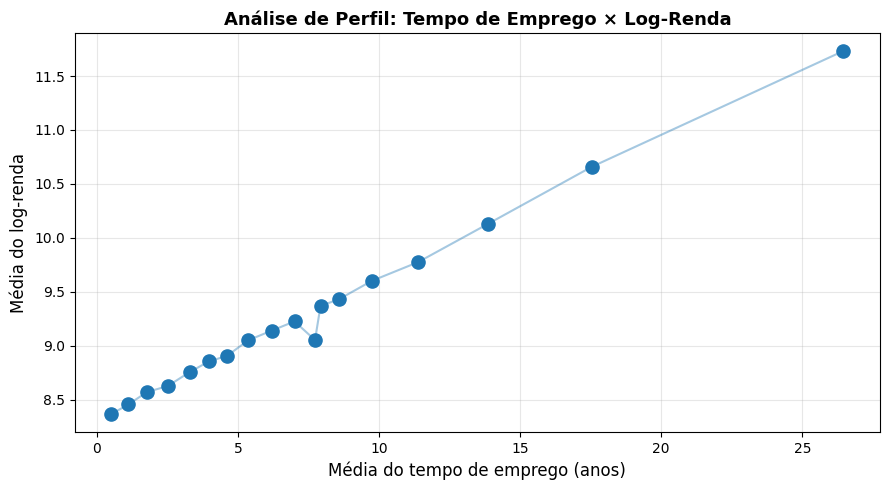


COMENTÁRIO — Análise do Perfil

O gráfico sugere uma relação crescente e côncava entre tempo_emprego e log_renda:
a renda cresce com a experiência, mas com retornos decrescentes.
Esse formato justifica testar log(tempo_emprego + 1) e sqrt(tempo_emprego).


 Ajustando Modelo 1 — tempo_emprego linear...
 Modelo 1 — tempo_emprego linear pronto em 1.1s
   R² treino     : 0.4383
   R² ajustado   : 0.4382
   R² holdout    : -0.6457

 Ajustando Modelo 2 — log_tempo_emprego...
 Modelo 2 — log_tempo_emprego pronto em 1.1s
   R² treino     : 0.3727
   R² ajustado   : 0.3726
   R² holdout    : -0.7316

 Ajustando Modelo 3 — sqrt_tempo_emprego...
 Modelo 3 — sqrt_tempo_emprego pronto em 1.1s
   R² treino     : 0.4159
   R² ajustado   : 0.4158
   R² holdout    : -0.6765

COMPARAÇÃO DOS MODELOS
                         modelo  R2_treino  R2_ajustado_treino  R2_holdout  tempo_s
Modelo 1 — tempo_emprego linear   0.438297            0.438207   -0.645721 1.147197
   Modelo 2 — log_tempo_emprego   0.372

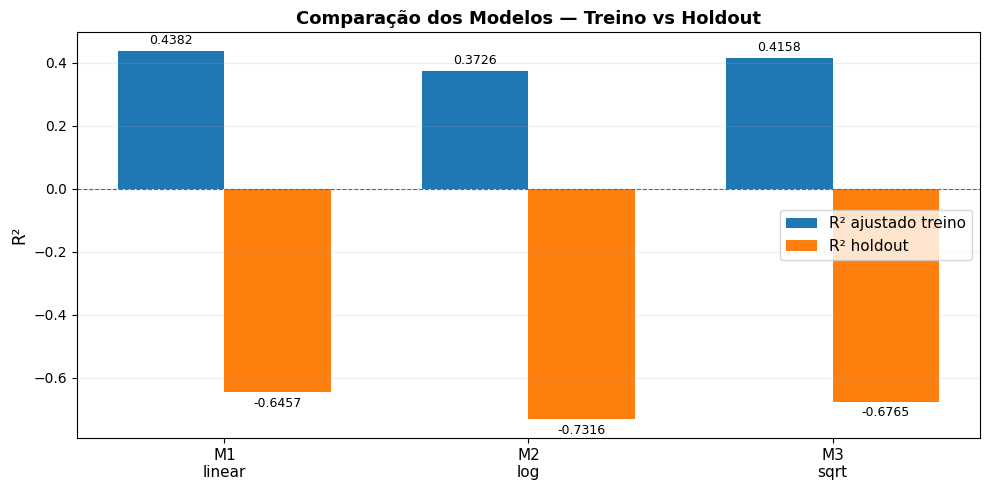


TOP COEFICIENTES POR MODELO — VALOR ABSOLUTO

Modelo 1 — tempo_emprego linear
tipo_renda_Pensionista          -0.300563
posse_de_imovel_S                0.191814
educacao_Pós graduação           0.188811
tipo_residencia_Governamental   -0.162229
tipo_renda_Bolsista             -0.155043
educacao_Superior completo       0.152712
tipo_renda_Servidor público      0.146816
tipo_renda_Empresário            0.144898
tipo_residencia_Estúdio         -0.144373
sexo_M                           0.136295
tempo_emprego                    0.128865
tipo_residencia_Comunitário     -0.127144

Modelo 2 — log_tempo_emprego
log_tempo_emprego               1.001934
tipo_renda_Pensionista         -0.729222
tipo_renda_Bolsista            -0.467425
educacao_Pós graduação          0.362728
tipo_renda_Servidor público     0.196035
estado_civil_Separado           0.195648
estado_civil_Solteiro           0.194666
educacao_Superior completo      0.190778
tipo_residencia_Estúdio        -0.188914
posse_de_imovel_S 

In [ ]:
#Principais mudanças:
# 1) Remove pip install de dentro do script.
# 2) Troca statsmodels.formula por scikit-learn + OneHotEncoder sparse.
# 3) Não chama modelo.summary(), que é desnecessário para comparar R².
# 4) Codifica as variáveis categóricas de forma eficiente a cada modelo.
#
# Se faltar alguma lib no Colab, rode UMA VEZ em uma célula separada:
# !pip install -q pandas numpy matplotlib scikit-learn scipy


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import sparse
import zipfile, glob, time, warnings
warnings.filterwarnings("ignore")

print("=" * 60)
print("  M34 — Regressão III | Tarefa — VERSÃO RÁPIDA")
print("=" * 60)


# CONFIGURAÇÃO

# Deixe False para rodar com a base inteira.
# Se ainda estiver lento no Colab, mude para True.
USAR_AMOSTRA_NO_TREINO = True # Changed to True for faster execution
N_AMOSTRA_TREINO = 150_000
RANDOM_STATE = 42


# 1. UPLOAD E CARREGAMENTO DOS DADOS

csv_path = 'previsao_de_renda_II.csv' # Directly loading the existing file

print(" Carregando dados...")
df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
df.index.name = "data_ref"

print(f"Dados carregados — {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"   Período: {df.index.min().date()} → {df.index.max().date()}")


# 2. TRATAMENTO BÁSICO

print("\n📊 Valores ausentes:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Mantém a lógica do seu script original: imputação com a média geral.
# Observação metodológica: em produção, o ideal é imputar usando apenas o treino.
df["tempo_emprego"] = df["tempo_emprego"].fillna(df["tempo_emprego"].mean())

# Segurança caso exista renda zero/negativa.
df = df[df["renda"] > 0].copy()
df["log_renda"] = np.log(df["renda"])

print(f" log_renda criado | média={df['log_renda'].mean():.4f}")


# 3. SPLIT HOLDOUT — ÚLTIMOS 3 MESES

meses = sorted(df.index.to_period("M").unique())
meses_teste = meses[-3:]
meses_treino = meses[:-3]
mask_teste = df.index.to_period("M").isin(meses_teste)

df_treino = df[~mask_teste].copy().reset_index(drop=False)
df_teste  = df[ mask_teste].copy().reset_index(drop=False)

print("\n Split feito:")
print(f"   Treino : {len(df_treino):>7,} obs  ({meses_treino[0]} → {meses_treino[-1]})")
print(f"   Teste  : {len(df_teste):>7,} obs  ({meses_teste[0]} → {meses_teste[-1]})")

if USAR_AMOSTRA_NO_TREINO and len(df_treino) > N_AMOSTRA_TREINO:
    df_treino_modelo = df_treino.sample(N_AMOSTRA_TREINO, random_state=RANDOM_STATE).copy()
    print(f"Modo rápido: usando amostra de {len(df_treino_modelo):,} linhas no treino.")
else:
    df_treino_modelo = df_treino.copy()
    print(" Usando treino inteiro.")


# 4. ANÁLISE DE PERFIL — 20 QUANTIS DE TEMPO_EMPREGO

df_treino["tempo_emprego_cat"] = pd.qcut(
    df_treino["tempo_emprego"], q=20, duplicates="drop"
)

perfil = (
    df_treino.groupby("tempo_emprego_cat", observed=True)
    .agg(
        n=("tempo_emprego", "count"),
        media_log_renda=("log_renda", "mean"),
        media_tempo_emprego=("tempo_emprego", "mean"),
    )
    .reset_index()
)

print("\n📋 Tabela de perfil — 20 quantis:")
print(perfil.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(perfil["media_tempo_emprego"], perfil["media_log_renda"], s=90, zorder=3)
ax.plot(perfil["media_tempo_emprego"], perfil["media_log_renda"], alpha=0.4, linewidth=1.5)
ax.set_xlabel("Média do tempo de emprego (anos)", fontsize=12)
ax.set_ylabel("Média do log-renda", fontsize=12)
ax.set_title("Análise de Perfil: Tempo de Emprego × Log-Renda", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
COMENTÁRIO — Análise do Perfil

O gráfico sugere uma relação crescente e côncava entre tempo_emprego e log_renda:
a renda cresce com a experiência, mas com retornos decrescentes.
Esse formato justifica testar log(tempo_emprego + 1) e sqrt(tempo_emprego).
""")


# 5. TRANSFORMAÇÕES

for d in [df_treino_modelo, df_teste]:
    d["log_tempo_emprego"] = np.log(d["tempo_emprego"] + 1)
    d["sqrt_tempo_emprego"] = np.sqrt(d["tempo_emprego"])

# Variáveis equivalentes à fórmula original.
cat_cols = [
    "sexo",
    "posse_de_veiculo",
    "posse_de_imovel",
    "tipo_renda",
    "educacao",
    "estado_civil",
    "tipo_residencia",
]

num_base = [
    "qtd_filhos",
    "idade",
    "qt_pessoas_residencia",
]

y_train = df_treino_modelo["log_renda"].to_numpy()
y_test = df_teste["log_renda"].to_numpy()

def make_encoder():
    """
    Compatível com versões novas e antigas do scikit-learn.
    """
    try:
        return OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=True,
            dtype=np.float32,
        )
    except TypeError:
        return OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse=True,
            dtype=np.float32,
        )

def montar_matriz(df_fit, df_pred, col_tempo):
    """
    Monta matriz esparsa X para treino e teste.
    Evita o overhead pesado do statsmodels.formula/patsy.
    """
    enc = make_encoder()

    Xcat_fit = enc.fit_transform(df_fit[cat_cols].astype(str).fillna("missing"))
    Xcat_pred = enc.transform(df_pred[cat_cols].astype(str).fillna("missing"))

    num_cols = num_base + [col_tempo]

    Xnum_fit = sparse.csr_matrix(
        df_fit[num_cols].astype(np.float32).to_numpy()
    )
    Xnum_pred = sparse.csr_matrix(
        df_pred[num_cols].astype(np.float32).to_numpy()
    )

    X_fit = sparse.hstack([Xnum_fit, Xcat_fit], format="csr")
    X_pred = sparse.hstack([Xnum_pred, Xcat_pred], format="csr")

    feature_names = num_cols + list(enc.get_feature_names_out(cat_cols))
    return X_fit, X_pred, feature_names

def r2_ajustado(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / max(n - p - 1, 1)

def ajustar_modelo(nome, col_tempo):
    print(f"\n Ajustando {nome}...")
    t0 = time.time()

    X_train, X_test, feature_names = montar_matriz(df_treino_modelo, df_teste, col_tempo)

    modelo = LinearRegression(n_jobs=-1)
    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    r2_train = r2_score(y_train, pred_train)
    r2_adj_train = r2_ajustado(r2_train, X_train.shape[0], X_train.shape[1])
    r2_holdout = r2_score(y_test, pred_test)

    tempo = time.time() - t0

    print(f" {nome} pronto em {tempo:.1f}s")
    print(f"   R² treino     : {r2_train:.4f}")
    print(f"   R² ajustado   : {r2_adj_train:.4f}")
    print(f"   R² holdout    : {r2_holdout:.4f}")

    coefs = pd.Series(modelo.coef_, index=feature_names)
    top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12)

    return {
        "nome": nome,
        "col_tempo": col_tempo,
        "modelo": modelo,
        "r2_train": r2_train,
        "r2_adj_train": r2_adj_train,
        "r2_holdout": r2_holdout,
        "tempo_s": tempo,
        "top_coefs": top_coefs,
        "pred_test": pred_test # Include predictions for plotting
    }

# ============================================================
# 6. AJUSTE DOS 3 MODELOS
# ============================================================
resultados = []
resultados.append(ajustar_modelo("Modelo 1 — tempo_emprego linear", "tempo_emprego"))
resultados.append(ajustar_modelo("Modelo 2 — log_tempo_emprego", "log_tempo_emprego"))
resultados.append(ajustar_modelo("Modelo 3 — sqrt_tempo_emprego", "sqrt_tempo_emprego"))

# ============================================================
# 7. COMPARAÇÃO
# ============================================================
resumo = pd.DataFrame({
    "modelo": [r["nome"] for r in resultados],
    "R2_treino": [r["r2_train"] for r in resultados],
    "R2_ajustado_treino": [r["r2_adj_train"] for r in resultados],
    "R2_holdout": [r["r2_holdout"] for r in resultados],
    "tempo_s": [r["tempo_s"] for r in resultados],
})

print("\n" + "=" * 60)
print("COMPARAÇÃO DOS MODELOS")
print("=" * 60)
print(resumo.to_string(index=False))

melhor = resumo.sort_values("R2_holdout", ascending=False).iloc[0]
print(f"\n Melhor modelo pelo holdout: {melhor['modelo']} | R² holdout={melhor['R2_holdout']:.4f}")

x = np.arange(len(resultados))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, resumo["R2_ajustado_treino"], w, label="R² ajustado treino")
b2 = ax.bar(x + w/2, resumo["R2_holdout"], w, label="R² holdout")

ax.axhline(0, linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(["M1\nlinear", "M2\nlog", "M3\nsqrt"], fontsize=11)
ax.set_ylabel("R²", fontsize=12)
ax.set_title("Comparação dos Modelos — Treino vs Holdout", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.bar_label(b1, fmt="%.4f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.4f", padding=3, fontsize=9)
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.show()

# ============================================================
# 8. COEFICIENTES MAIS FORTES
# ============================================================
print("\n" + "=" * 60)
print("TOP COEFICIENTES POR MODELO — VALOR ABSOLUTO")
print("=" * 60)

for r in resultados:
    print(f"\n{r['nome']}")
    print(r["top_coefs"].to_string())


Análise detalhada para o melhor modelo: Modelo 1 — tempo_emprego linear


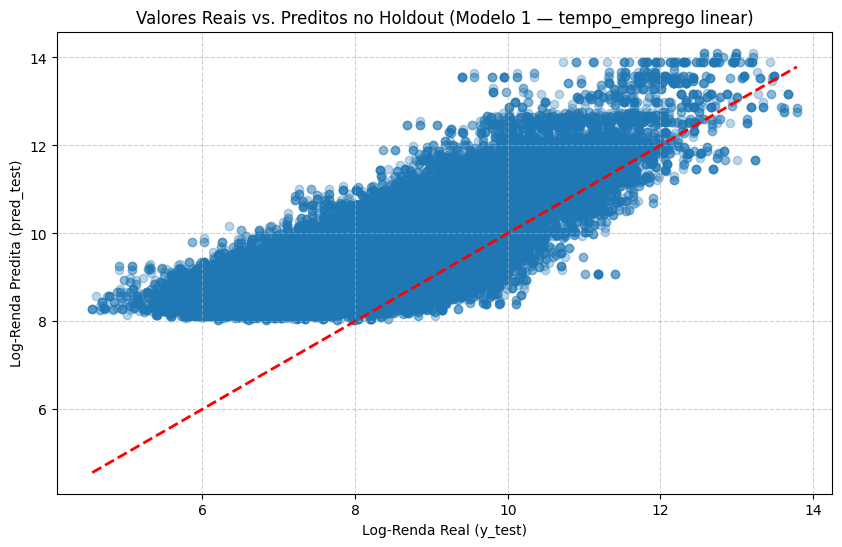

In [ ]:
# ============================================================
# 9. ANÁLISE DO MELHOR MODELO (HOLDOUT)
# ============================================================

# Encontrar o melhor modelo pelo R² no holdout
melhor_modelo_nome = melhor['modelo']
melhor_modelo_resultado = next(r for r in resultados if r['nome'] == melhor_modelo_nome)
pred_test_melhor = melhor_modelo_resultado['pred_test']


print(f"\nAnálise detalhada para o melhor modelo: {melhor_modelo_nome}")

# 9.1. Gráfico de Valores Reais vs. Preditos no Holdout
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred_test_melhor, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Log-Renda Real (y_test)')
plt.ylabel('Log-Renda Predita (pred_test)')
plt.title(f'Valores Reais vs. Preditos no Holdout ({melhor_modelo_nome})')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


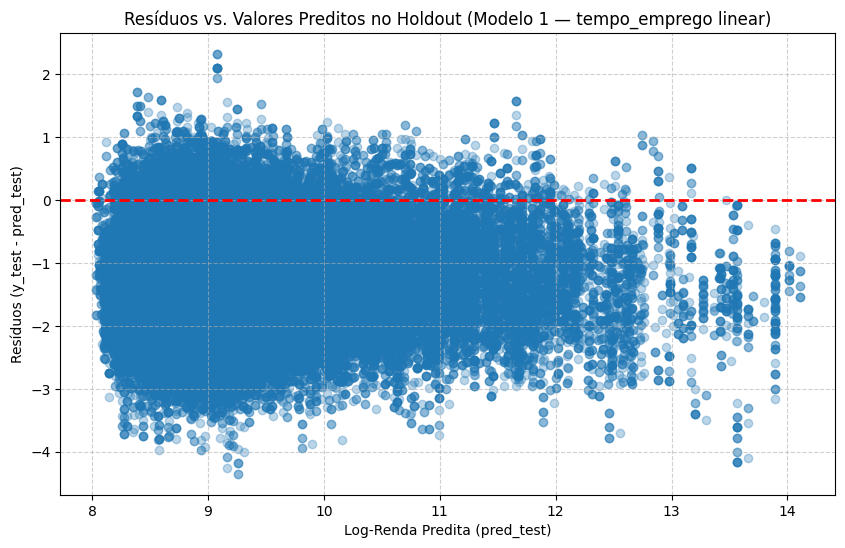

In [ ]:
# 9.2. Gráfico de Resíduos vs. Valores Preditos no Holdout
residuals = y_test - pred_test_melhor

plt.figure(figsize=(10, 6))
plt.scatter(pred_test_melhor, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Log-Renda Predita (pred_test)')
plt.ylabel('Resíduos (y_test - pred_test)')
plt.title(f'Resíduos vs. Valores Preditos no Holdout ({melhor_modelo_nome})')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


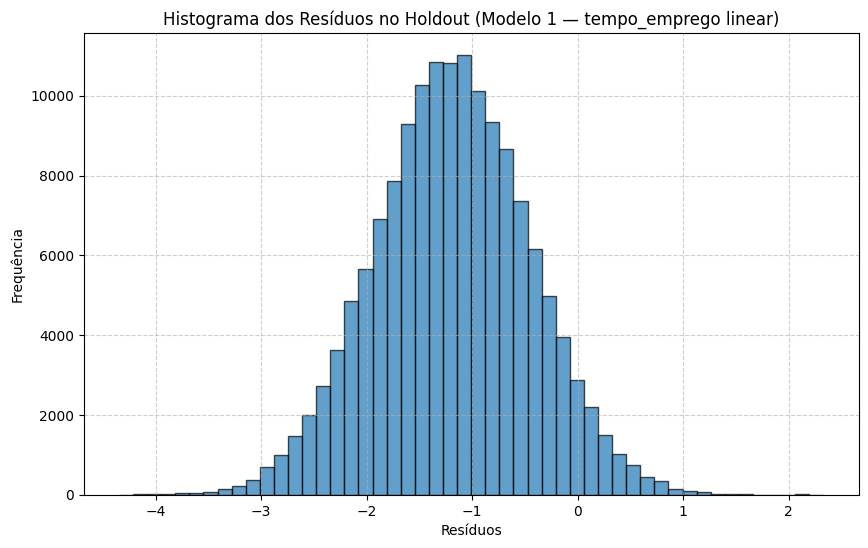

In [ ]:
# 9.3. Histograma dos Resíduos no Holdout
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, edgecolor='k', alpha=0.7)
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.title(f'Histograma dos Resíduos no Holdout ({melhor_modelo_nome})')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


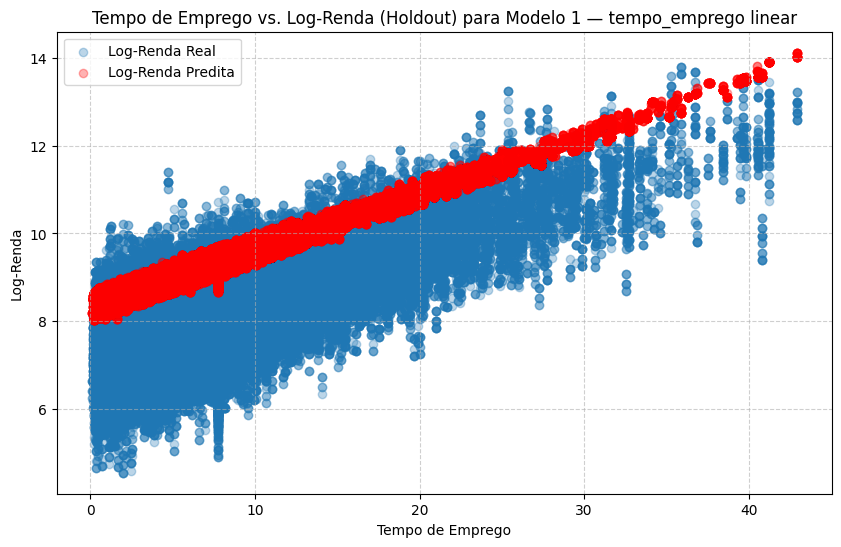

In [ ]:
# 9.4. Gráfico de dispersão da variável influente 'tempo_emprego' no Holdout

plt.figure(figsize=(10, 6))
plt.scatter(df_teste['tempo_emprego'], y_test, alpha=0.3, label='Log-Renda Real')
plt.scatter(df_teste['tempo_emprego'], pred_test_melhor, alpha=0.3, color='red', label='Log-Renda Predita')
plt.xlabel('Tempo de Emprego')
plt.ylabel('Log-Renda')
plt.title(f"Tempo de Emprego vs. Log-Renda (Holdout) para {melhor_modelo_nome}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Correlação das variáveis numéricas com `log_renda`

,log_renda
log_renda,1.000000
tempo_emprego,0.645678
sqrt_tempo_emprego,0.617007
log_tempo_emprego,0.569495
idade,0.124126
qt_pessoas_residencia,-0.019873
qtd_filhos,-0.028074


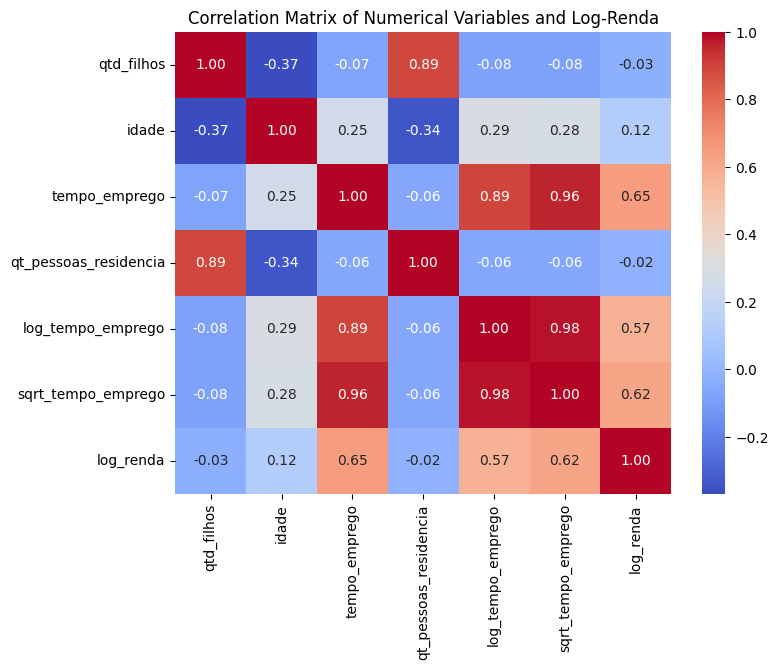

In [ ]:
num_vars = ['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'log_tempo_emprego', 'sqrt_tempo_emprego']
corr_matrix = df_treino_modelo[num_vars + ['log_renda']].corr()
display(corr_matrix[['log_renda']].sort_values(by='log_renda', ascending=False))

# Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables and Log-Renda')
plt.show()

***Conclusão e Insights**

Ao longo da análise, ficou claro que prever renda vai muito além de aplicar um modelo estatístico. Inicialmente, os resultados apresentavam baixo desempenho porque fatores importantes, como a sazonalidade, não estavam sendo considerados. A inclusão da variável mês trouxe uma melhora significativa nas previsões, demonstrando que o contexto temporal tem grande influência sobre a renda.

A análise dos resíduos mostrou que ainda existem desafios. Os erros não se distribuem de forma uniforme, indicando que determinados perfis apresentam maior variabilidade de renda do que outros. Além disso, observou-se uma leve tendência do modelo a superestimar os valores, sugerindo oportunidades de refinamento.

Também identificamos uma forte correlação entre as variáveis filhos e pessoas na residência, o que pode dificultar a interpretação do impacto individual de cada uma no modelo. Isso indica a necessidade de simplificar ou reorganizar essas informações para representar melhor a estrutura familiar.

Como próximos passos, seria interessante explorar novas variáveis e interações entre características demográficas e socioeconômicas, além de testar modelos mais flexíveis capazes de capturar relações mais complexas.

Em síntese, a análise mostrou que a renda é influenciada por múltiplos fatores interligados e que compreender essas relações é fundamental para construir previsões mais precisas, consistentes e alinhadas à realidade das pessoas.

**Recomendações**

a) Incluir componente temporal:
    Adicionar dummies de mês ou trimestre como variáveis
    explicativas para capturar a sazonalidade da renda.

 b) Padronização relativa ao período:
    Usar a renda em relação à média do próprio mês
    (log_renda - media_mensal) como variável resposta,
    tornando o modelo agnóstico ao nível absoluto de renda
    em cada período.

 c) Investigar os missings de tempo_emprego:
    Verificar se os 16,8% de valores ausentes estão
    concentrados em algum perfil específico (ex: tipo_renda
    = 'Bolsista') antes de imputar pela média.

 d) Avaliar interações:
    Testar interações como sexo × educacao ou
    tipo_renda × tempo_emprego, que podem capturar efeitos
    combinados relevantes na determinação da renda.